# Tree Models Demo

DecisionTree, RandomForest, GradientBoosting, and XGBoost from scratch.

In [2]:
import sys
import os

# Menambahkan folder utama ke daftar pencarian Python
sys.path.append(os.path.abspath("..")) 

import mlengine as mle
print(mle.__version__)

0.1.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
import mlengine as mle

X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

## Decision Tree — Depth vs Accuracy

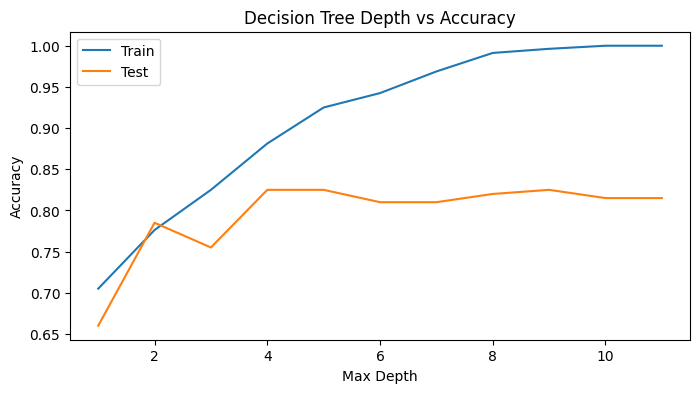

In [4]:
depths = range(1, 12)
train_scores, test_scores = [], []
for d in depths:
    tree = mle.DecisionTree(max_depth=d).fit(X_tr, y_tr)
    train_scores.append(tree.score(X_tr, y_tr))
    test_scores.append(tree.score(X_te, y_te))

plt.figure(figsize=(8,4))
plt.plot(depths, train_scores, label='Train')
plt.plot(depths, test_scores, label='Test')
plt.xlabel('Max Depth'); plt.ylabel('Accuracy'); plt.title('Decision Tree Depth vs Accuracy')
plt.legend(); plt.show()

## Random Forest — Feature Importances

Test accuracy: 0.9000
OOB score:     0.8962


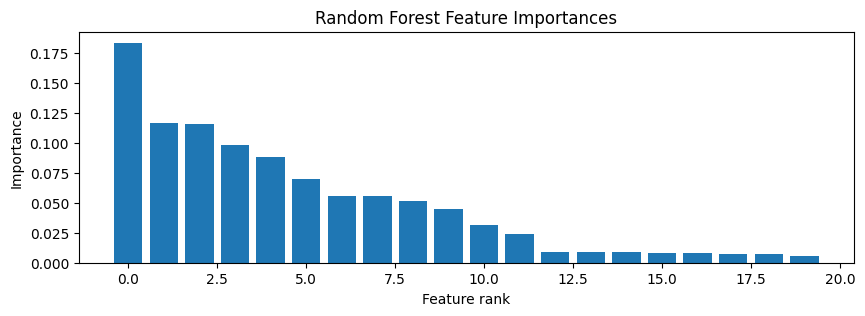

In [5]:
rf = mle.RandomForest(n_estimators=100, max_depth=5, oob_score=True, random_state=42)
rf.fit(X_tr, y_tr)
print(f'Test accuracy: {rf.score(X_te, y_te):.4f}')
print(f'OOB score:     {rf.oob_score_:.4f}')

imp = rf.feature_importances_
plt.figure(figsize=(10,3))
plt.bar(range(len(imp)), sorted(imp, reverse=True))
plt.xlabel('Feature rank'); plt.ylabel('Importance')
plt.title('Random Forest Feature Importances'); plt.show()

## Gradient Boosting — Learning Curve

GradientBoosting test accuracy: 0.9000


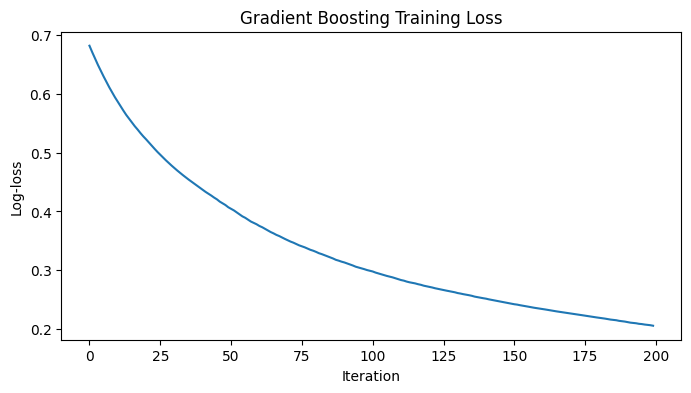

In [6]:
gb = mle.GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=3, random_state=0)
gb.fit(X_tr, y_tr)
print(f'GradientBoosting test accuracy: {gb.score(X_te, y_te):.4f}')

plt.figure(figsize=(8,4))
plt.plot(gb.train_losses_)
plt.xlabel('Iteration'); plt.ylabel('Log-loss'); plt.title('Gradient Boosting Training Loss')
plt.show()

## XGBoost — Comparison

In [7]:
xgb = mle.XGBoostClassifier(n_estimators=100, learning_rate=0.1, max_depth=4,
                              reg_lambda=1.0, gamma=0.0, random_state=0)
xgb.fit(X_tr, y_tr)
print(f'XGBoost test accuracy: {xgb.score(X_te, y_te):.4f}')

models = {
    'DecisionTree(d=5)': mle.DecisionTree(max_depth=5),
    'RandomForest(100)': mle.RandomForest(n_estimators=100, max_depth=5, random_state=0),
    'GradientBoosting':  mle.GradientBoostingClassifier(n_estimators=100, random_state=0),
    'XGBoost':           mle.XGBoostClassifier(n_estimators=100, random_state=0),
}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    print(f'{name:30s}: {m.score(X_te, y_te):.4f}')

XGBoost test accuracy: 0.9350
DecisionTree(d=5)             : 0.8250
RandomForest(100)             : 0.9050
GradientBoosting              : 0.8800
XGBoost                       : 0.9200
